# 04 — FASE 3: Analytics

> **A pergunta desta fase:** como coloco isto na mão de quem decide?

Esta é a única fase que outras pessoas veem. E é onde mais se erra, porque a
tentação é mostrar *tudo o que temos* em vez de *o que responde a pergunta*.

Três mudanças de postura em relação às fases anteriores:

| | Fases 1 e 2 | Fase 3 |
|---|---|---|
| **Público** | quem constrói o dado | quem usa o dado |
| **Prioridade** | completude e fidelidade | clareza e velocidade de leitura |
| **Métrica de sucesso** | o número está certo | a pessoa entendeu o número |

E uma regra de arquitetura: **o app só lê a camada gold**. Ele não conhece a API,
não faz JOIN e não aplica regra de negócio. Se ele precisasse fazer qualquer uma
dessas coisas, o erro estaria na fase 2, não aqui.

In [1]:
# --- Preparação do ambiente (rode esta célula primeiro) --------------------
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src"))

import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print("Raiz do projeto:", RAIZ)
print("Python:", sys.version.split()[0])


Raiz do projeto: c:\dev\Estudo-MDS
Python: 3.12.10


In [2]:
from f1_pipeline import config
from f1_pipeline.processing.gold import load_gold

gold = load_gold()

for nome, df in gold.items():
    print(f"{nome:<32} {len(df):>5} linhas")


agg_driver_season                   89 linhas
agg_constructor_season              40 linhas
agg_race_summary                    90 linhas
agg_championship_progression      2006 linhas
agg_circuit_stats                   28 linhas
agg_teammate_battle                 90 linhas


## 1. Antes do gráfico: escolha a forma, não a cor

A ordem correta para construir qualquer visualização:

1. **Qual é o trabalho do dado?** comparar magnitudes? mostrar evolução? destacar
   um único número? mostrar polaridade (acima/abaixo de zero)?
2. **A forma decorre do trabalho** — e às vezes a resposta é *não fazer gráfico*.
3. **A cor vem por último**, e sempre com uma função.

| O trabalho do dado | Forma certa |
|---|---|
| comparar magnitudes entre categorias | **barra** (horizontal se os nomes são longos) |
| evolução ao longo do tempo | **linha** |
| um único número é a resposta | **número grande**, sem gráfico |
| parte do todo, poucas fatias, soma 100% | barra empilhada (raramente pizza) |
| relação entre duas medidas | dispersão |

E a cor tem três papéis distintos, que não se misturam:

* **categórica** — identidade (cada piloto tem *seu* tom, fixo);
* **sequencial** — magnitude (um tom só, do claro ao escuro);
* **status** — estado (aprovado/reprovado), sempre com texto junto.

> **A regra que mais salva gráficos:** a cor segue a **entidade**, nunca a
> posição no ranking. Se a cor mudasse conforme o filtro, o leitor perderia a
> referência a cada clique.

In [3]:
import sys

import matplotlib.pyplot as plt

# Reaproveitamos a paleta do app — a mesma cor nos notebooks e na tela final.
sys.path.insert(0, str(RAIZ / "app"))
import theme

print("Paleta categórica (ordem fixa, validada para daltonismo):")
for i, cor in enumerate(theme.CATEGORICA, start=1):
    print(f"  slot {i}: {cor}")


Paleta categórica (ordem fixa, validada para daltonismo):
  slot 1: #2a78d6
  slot 2: #eb6834
  slot 3: #1baf7a
  slot 4: #eda100
  slot 5: #e87ba4
  slot 6: #008300
  slot 7: #4a3aa7
  slot 8: #e34948


### Por que usamos matplotlib aqui e Plotly no app?

Não é preferência: é o **meio de exibição** decidindo a ferramenta.

* **Notebook** → matplotlib. Gera imagem estática, que fica embutida no `.ipynb`
  e **aparece no GitHub** para quem só lê o notebook, sem rodar nada.
* **App** → Plotly. Gera gráfico interativo com hover e tooltip, que só faz
  sentido em uma página que a pessoa usa de verdade.

Mesma paleta, mesmas regras, ferramentas diferentes.

In [4]:
def estilo_base(ax, titulo: str, rotulo_x: str = "", rotulo_y: str = "", grade: str = "x"):
    """Aplica o estilo do projeto: pouca tinta, muita informação."""
    ax.set_title(titulo, color=theme.TINTA_PRIMARIA, fontsize=13, loc="left", pad=14)
    ax.set_xlabel(rotulo_x, color=theme.TINTA_SECUNDARIA, fontsize=11)
    ax.set_ylabel(rotulo_y, color=theme.TINTA_SECUNDARIA, fontsize=11)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color(theme.EIXO)
    ax.tick_params(colors=theme.TINTA_DISCRETA, labelsize=10)
    if grade:
        ax.grid(axis=grade, color=theme.GRADE, linewidth=0.8)
        ax.set_axisbelow(True)   # a grade fica ATRÁS das barras
    return ax


plt.rcParams.update({
    "figure.facecolor": theme.SUPERFICIE,
    "axes.facecolor": theme.SUPERFICIE,
    "font.size": 11,
    "figure.dpi": 110,
})
print("Estilo configurado.")


Estilo configurado.


## 2. Quando a resposta é um número, mostre o número

Antes de qualquer gráfico: existe pergunta cuja melhor resposta é uma frase e um
número. Gráfico ali só adiciona trabalho de leitura.

In [5]:
temporada = int(gold["agg_driver_season"]["season"].max())

pilotos = gold["agg_driver_season"].query("season == @temporada")
equipes = gold["agg_constructor_season"].query("season == @temporada")
corridas = gold["agg_race_summary"].query("season == @temporada")

campeao = pilotos.iloc[0]

print(f"TEMPORADA {temporada}")
print("=" * 46)
print(f"{'Campeão':<24} {campeao['piloto']}")
print(f"{'Pontos':<24} {campeao['pontos']:.0f}")
print(f"{'Vitórias / Pódios':<24} {int(campeao['vitorias'])} / {int(campeao['podios'])}")
print(f"{'Equipe campeã':<24} {equipes.iloc[0]['equipe']} ({equipes.iloc[0]['pontos']:.0f} pts)")
print(f"{'Corridas':<24} {len(corridas)}")
print(f"{'Abandonos no total':<24} {int(corridas['abandonos'].sum())}")
print(f"{'Pit stop médio':<24} {corridas['duracao_media_pit_s'].mean():.1f} s")


TEMPORADA 2024
Campeão                  Max Verstappen
Pontos                   399
Vitórias / Pódios        9 / 14
Equipe campeã            McLaren (609 pts)
Corridas                 24
Abandonos no total       54
Pit stop médio           24.7 s


## 3. Barra horizontal: comparar magnitudes

A forma certa quando as categorias têm **nomes** (que precisam caber) e a
pergunta é "quem tem mais?".

Três detalhes que fazem diferença:

* **ordenar** do maior para o menor — o ranking vira a própria estrutura visual;
* **rótulo direto na ponta** da barra — o leitor não precisa mirar no eixo;
* **uma cor só** — não há identidade a distinguir aqui, todas as barras são a
  mesma coisa medida em lugares diferentes. Colorir cada barra de um jeito seria
  *ruído*, não informação.

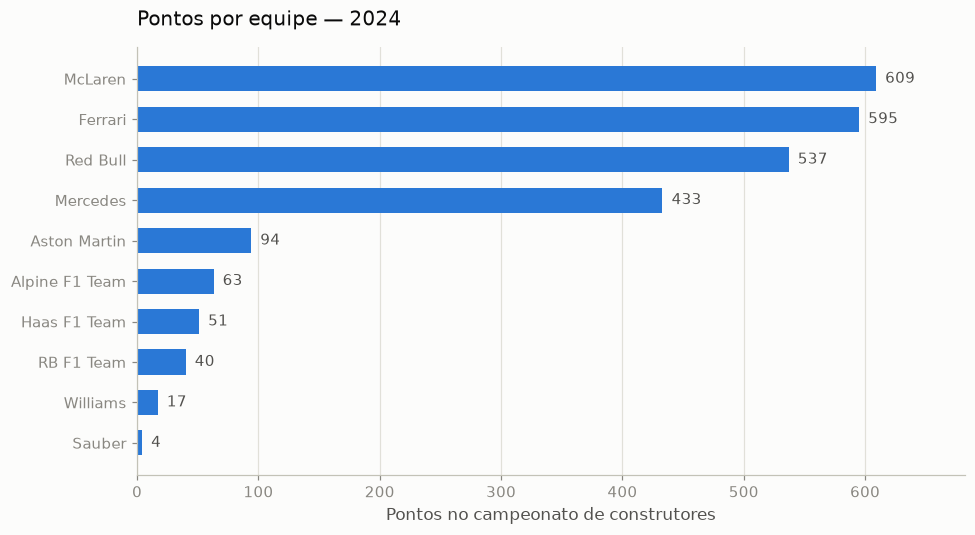

In [6]:
dados = equipes.sort_values("pontos")

figura, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(dados["equipe"], dados["pontos"], color=theme.CATEGORICA[0], height=0.62)
ax.bar_label(barras, fmt="%.0f", padding=6, color=theme.TINTA_SECUNDARIA, fontsize=10)
ax.set_xlim(0, dados["pontos"].max() * 1.12)
estilo_base(ax, f"Pontos por equipe — {temporada}", "Pontos no campeonato de construtores")
plt.tight_layout()
plt.show()


## 4. Linha: evolução no tempo

Aqui a cor tem função de **identidade**: cada piloto precisa ser rastreável ao
longo do gráfico. Por isso usamos a paleta categórica, em ordem fixa.

**Por que no máximo 8 séries?** Porque nenhuma paleta segura distingue mais do
que isso — inclusive para quem tem daltonismo. Precisando de mais, a resposta
certa não é inventar uma nona cor: é agrupar em "outros", separar em vários
gráficos pequenos ou filtrar.

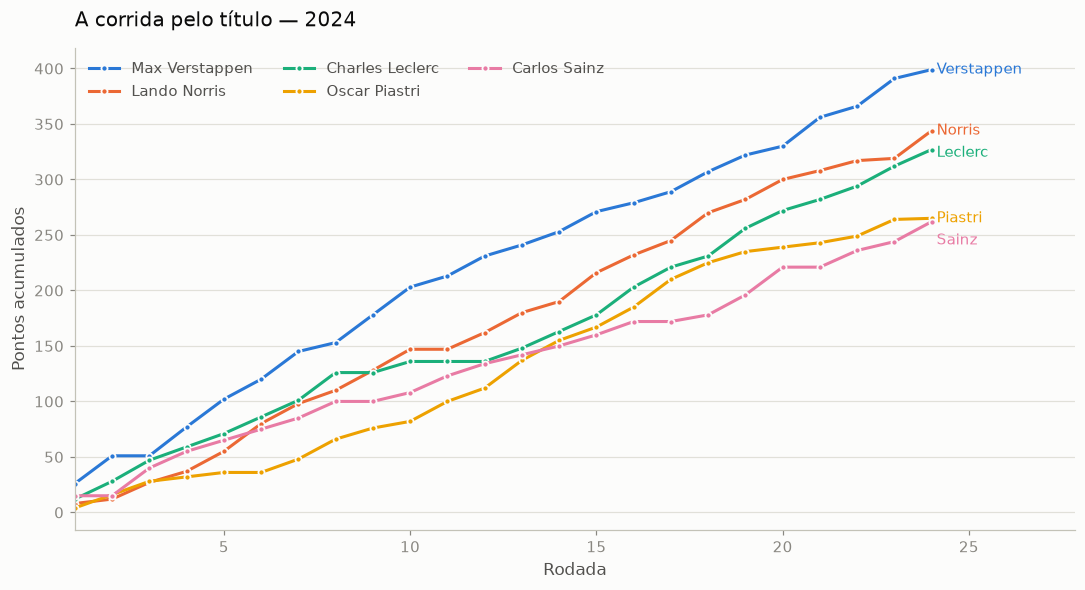

In [7]:
progressao = gold["agg_championship_progression"].query("season == @temporada")
top_pilotos = pilotos.nlargest(5, "pontos")["piloto"].tolist()
cores = theme.cores_por_entidade(top_pilotos)

figura, ax = plt.subplots(figsize=(10, 5.5))
finais = []
for piloto in top_pilotos:
    serie = progressao[progressao["piloto"] == piloto].sort_values("rodada")
    ax.plot(serie["rodada"], serie["pontos_acumulados"],
            color=cores[piloto], linewidth=2, marker="o", markersize=4,
            markeredgecolor=theme.SUPERFICIE, markeredgewidth=1.2, label=piloto)
    ultimo = serie.iloc[-1]
    finais.append((ultimo["pontos_acumulados"], ultimo["rodada"], piloto))

# Rótulo direto no fim da linha dispensa procurar na legenda. Quando dois
# pilotos terminam quase empatados os rótulos se sobrepõem — então empurramos
# cada um para baixo o suficiente para manter uma distância mínima legível.
distancia_minima = 0.05 * progressao["pontos_acumulados"].max()
altura_anterior = None
for valor, rodada, piloto in sorted(finais, reverse=True):
    altura = valor if altura_anterior is None else min(valor, altura_anterior - distancia_minima)
    ax.annotate(f" {piloto.split()[-1]}", xy=(rodada, altura),
                color=cores[piloto], fontsize=10, va="center")
    altura_anterior = altura

ax.set_xlim(1, progressao["rodada"].max() * 1.16)
estilo_base(ax, f"A corrida pelo título — {temporada}", "Rodada", "Pontos acumulados", grade="y")
ax.legend(frameon=False, ncol=3, loc="upper left", fontsize=10, labelcolor=theme.TINTA_SECUNDARIA)
plt.tight_layout()
plt.show()


## 5. Barras agrupadas: duas medidas na MESMA escala

Largada média e chegada média são ambas "posição". Mesma unidade, mesma escala,
mesmo eixo: podem conviver.

> ⛔ **O erro de gráfico mais comum do mundo corporativo: o eixo duplo.** Colocar
> "pontos" e "taxa de abandono %" no mesmo gráfico com dois eixos Y permite ao
> autor (mesmo sem querer) *escolher* a narrativa, esticando uma escala em
> relação à outra. Medidas de escalas diferentes pedem **dois gráficos** — nunca
> dois eixos.

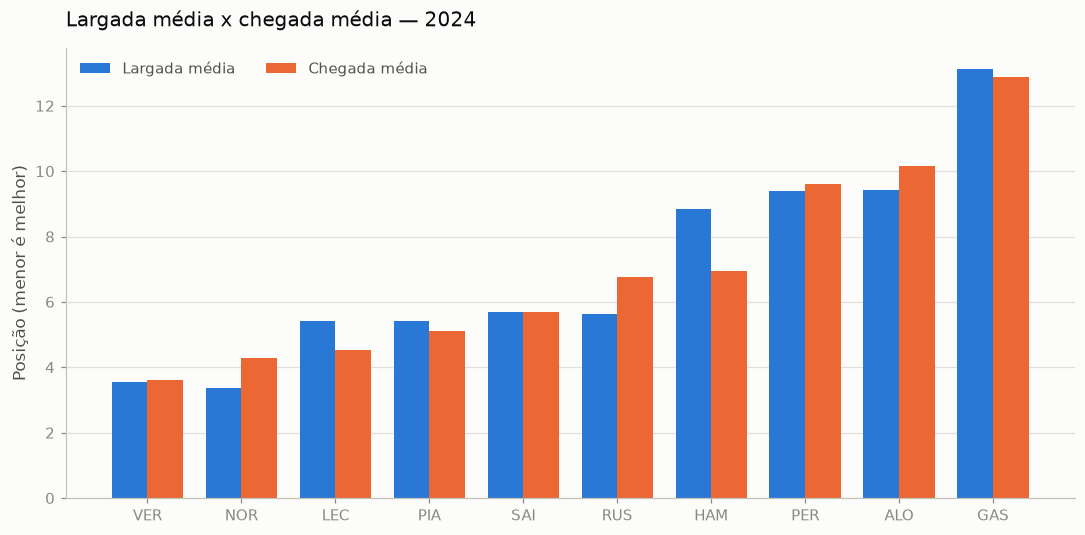

Barra de chegada mais baixa que a de largada = o piloto ganha posições na corrida.


In [8]:
import numpy as np

dados = pilotos.nlargest(10, "pontos")
posicoes = np.arange(len(dados))
largura = 0.38

figura, ax = plt.subplots(figsize=(10, 5))
ax.bar(posicoes - largura / 2, dados["media_grid"], largura,
       label="Largada média", color=theme.CATEGORICA[0])
ax.bar(posicoes + largura / 2, dados["media_chegada"], largura,
       label="Chegada média", color=theme.CATEGORICA[1])

ax.set_xticks(posicoes)
ax.set_xticklabels(dados["sigla"].fillna(dados["piloto"]))
estilo_base(ax, f"Largada média x chegada média — {temporada}", "", "Posição (menor é melhor)", grade="y")
ax.legend(frameon=False, ncol=2, fontsize=10, labelcolor=theme.TINTA_SECUNDARIA)
plt.tight_layout()
plt.show()

print("Barra de chegada mais baixa que a de largada = o piloto ganha posições na corrida.")


## 6. Um anti-padrão, lado a lado

A pizza é o gráfico mais usado e um dos menos eficazes. O olho humano compara
**comprimentos** com precisão e **ângulos** muito mal — principalmente quando as
fatias têm tamanhos parecidos.

Compare as duas visualizações dos mesmos dados. Na pizza, ordene mentalmente da
3ª à 6ª equipe. Na barra, o ranking já está pronto.

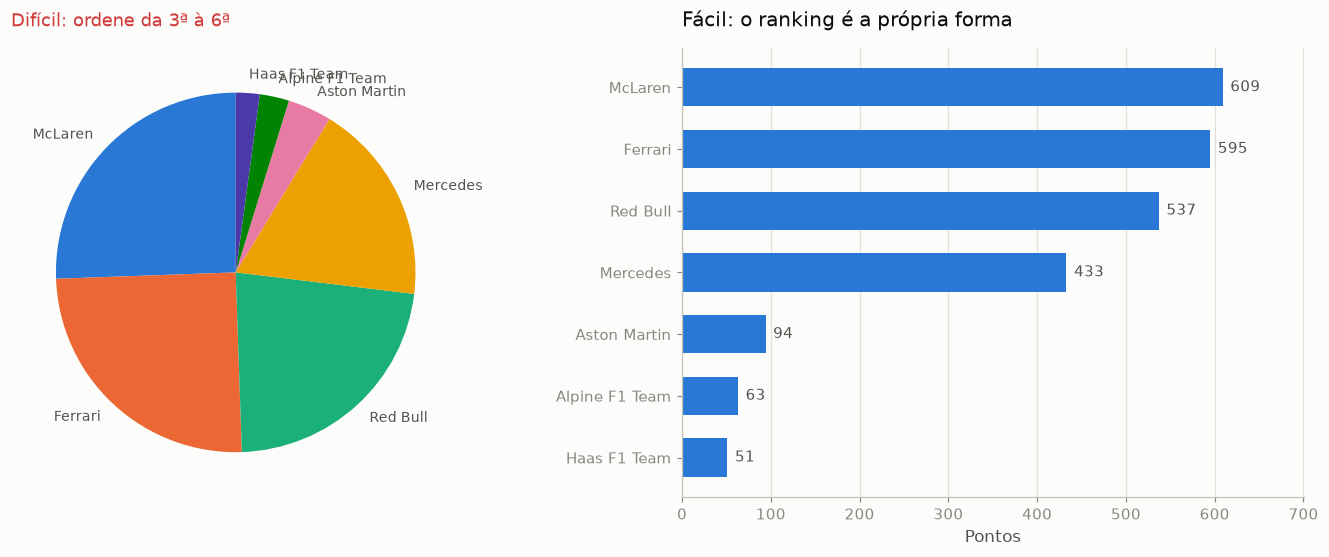

In [9]:
dados = equipes.head(7)

figura, (esquerda, direita) = plt.subplots(1, 2, figsize=(13, 5.2))

# ANTI-PADRÃO: pizza com muitas fatias parecidas
esquerda.pie(dados["pontos"], labels=dados["equipe"], colors=theme.CATEGORICA[:len(dados)],
             startangle=90, textprops={"fontsize": 9, "color": theme.TINTA_SECUNDARIA})
esquerda.set_title("Difícil: ordene da 3ª à 6ª", color=theme.STATUS["critico"],
                   fontsize=12, loc="left", pad=14)

# A MESMA informação, na forma certa
ordenado = dados.sort_values("pontos")
barras = direita.barh(ordenado["equipe"], ordenado["pontos"], color=theme.CATEGORICA[0], height=0.62)
direita.bar_label(barras, fmt="%.0f", padding=5, color=theme.TINTA_SECUNDARIA, fontsize=10)
direita.set_xlim(0, ordenado["pontos"].max() * 1.15)
estilo_base(direita, "Fácil: o ranking é a própria forma", "Pontos")
direita.title.set_color(theme.STATUS["bom"])

plt.tight_layout()
plt.show()


## 7. Fechando o ciclo: qualidade junto do número

Um painel que mostra números sem mostrar a confiabilidade deles está pedindo para
ser questionado na reunião. O app tem uma página inteira dedicada ao resultado
das validações — o **mesmo** relatório JSON gerado no notebook 02.

In [10]:
import json

caminho = config.REPORTS_DIR / "quality_report.json"
relatorio = json.loads(caminho.read_text(encoding="utf-8"))

print(f"Etapa            : {relatorio['etapa']}")
print(f"Gerado em        : {relatorio['gerado_em']}")
print(f"Status geral     : {'APROVADO' if relatorio['sucesso_geral'] else 'REPROVADO'}")
print(f"Tabelas validadas: {relatorio['tabelas_validadas']}")
print(f"Regras           : {relatorio['regras_executadas'] - relatorio['regras_reprovadas']}/{relatorio['regras_executadas']} aprovadas")

pd.DataFrame([
    {"tabela": r["tabela"], "regras": r["total_regras"],
     "aprovadas": r["regras_ok"], "linhas": r["linhas_avaliadas"],
     "status": "APROVADO" if r["sucesso"] else "REPROVADO"}
    for r in relatorio["resultados"]
])


Etapa            : processamento
Gerado em        : 2026-09-05T01:08:37+00:00
Status geral     : APROVADO
Tabelas validadas: 4
Regras           : 20/20 aprovadas


,tabela,regras,aprovadas,linhas,status
0,silver_fact_result,7,7,1799,APROVADO
1,silver_fact_qualifying,3,3,1798,APROVADO
2,gold_agg_driver_season,7,7,89,APROVADO
3,gold_agg_constructor_season,3,3,40,APROVADO


## 8. O aplicativo Streamlit

Tudo o que exploramos aqui vira uma interface que **não exige Python** de quem
usa. Para subir:

```bash
streamlit run app/streamlit_app.py
```

Abre em `http://localhost:8501`.

### Estrutura

```
app/
├── streamlit_app.py     ← página inicial: KPIs e visão geral
├── theme.py             ← paleta, template Plotly e componentes visuais
├── data_access.py       ← leitura da gold, com cache
└── pages/
    ├── 1_Campeonato.py            ← evolução dos pontos rodada a rodada
    ├── 2_Pilotos.py               ← perfil individual e duelo interno
    ├── 3_Construtores.py          ← equipes: pontos e confiabilidade
    ├── 4_Corridas_e_Circuitos.py  ← abandonos, pit stops e mapa
    └── 5_Qualidade_dos_Dados.py   ← o relatório do Great Expectations
```

O Streamlit monta o menu lateral sozinho a partir dos arquivos em `pages/`, na
ordem do nome.

### As três ideias de Streamlit que sustentam o app

**1. O script inteiro roda de novo a cada interação.** Não existe *callback*: a
pessoa mexe no filtro, o script executa do zero. Simples de escrever — e a razão
da ideia seguinte.

**2. `@st.cache_data` é obrigatório, não otimização.** Sem cache, todo clique
releria os arquivos Parquet do disco.

```python
@st.cache_data
def carregar_gold():
    return {nome: read_table(GOLD_DIR / nome) for nome in TABELAS}
```

**3. Widgets devolvem valores.** `st.selectbox(...)` retorna o valor escolhido —
o filtro é uma variável comum, e o resto do script é Python normal.

In [ ]:
# O app é curto justamente porque a inteligência ficou na camada gold:
for arquivo in sorted((RAIZ / "app").rglob("*.py")):
    linhas = len(arquivo.read_text(encoding="utf-8").splitlines())
    print(f"{str(arquivo.relative_to(RAIZ)):<44} {linhas:>4} linhas")


## 9. O projeto inteiro, em um comando

Depois de entender cada fase, vale ver o pipeline rodando de ponta a ponta —
é assim que ele viveria em produção, disparado por um agendador:

```bash
python scripts/run_pipeline.py --seasons 2021-2024
```

```
ingestão → bronze → [PORTÃO 1] → silver → [PORTÃO 2] → gold → [PORTÃO 3] → Data Docs
```

Opções úteis:

| Opção | Para quê |
|---|---|
| `--skip-ingest` | reprocessar a partir do raw, sem tocar na API |
| `--no-overwrite` | carga incremental: só o que ainda não existe |
| `--parar-se-reprovar` | comportamento de produção: qualidade bloqueia o pipeline |
| `--skip-quality` | pular a validação (útil só para depurar) |

## 10. Encerramento

### O que foi construído

| Fase | Entregas |
|---|---|
| **1. Ingestão** | cliente HTTP com rate limit, retry e paginação; camada raw particionada com manifesto e hash SHA-256; ingestão em fan-out para endpoints por rodada |
| **1.5 Qualidade** | 55 expectativas em 10 tabelas, nas três camadas; portão que bloqueia o pipeline; Data Docs em HTML; relatório JSON consumido pelo app |
| **2. Processamento** | bronze fiel à fonte; silver tipada com modelo estrela e regras de negócio; 6 marts na gold |
| **3. Analytics** | app Streamlit de 5 páginas, com paleta validada e a qualidade dos dados exposta ao usuário |

### As sete ideias que valem além deste projeto

1. **Camadas com responsabilidade única** — cada uma faz uma coisa.
2. **Raw é sagrado** — o dado bruto é a sua rede de segurança.
3. **Dado ruim não avisa** — validação explícita é a única defesa.
4. **Regra de negócio mora em um lugar só** — a silver.
5. **Modele a pergunta na gold** — se o consumidor faz JOIN, faltou trabalho.
6. **Idempotência** — rodar duas vezes não pode estragar nada.
7. **Forma antes de cor** — em visualização, clareza é uma decisão técnica.

### Para onde seguir

| Tema | O que investigar |
|---|---|
| **Orquestração** | Trocar `run_pipeline.py` por Airflow, Dagster ou Prefect: agendamento, retry por tarefa, backfill |
| **Transformação declarativa** | dbt para as camadas silver/gold, com testes e documentação gerada |
| **Volume** | Quando o pandas não couber na memória: Polars, DuckDB, Spark |
| **Formato de tabela** | Delta Lake ou Apache Iceberg: versionamento, *time travel*, transações |
| **Nuvem** | O mesmo desenho em S3/ADLS + Athena/Synapse + Power BI |
| **Streaming** | E se os dados chegassem volta a volta, ao vivo? Kafka + processamento contínuo |

### Exercícios finais

1. **Sprints.** Ingira `/{season}/sprint`, some os pontos e compare os totais com
   o campeonato oficial. Quantos pontos faltavam?
2. **Uma página nova.** Crie `6_Comparar_Pilotos.py`: dois pilotos lado a lado,
   em qualquer temporada. Que tabela gold falta? Crie-a.
3. **Uma métrica nova.** Defina e implemente um "índice de consistência" do
   piloto (dica: desvio-padrão das posições de chegada). Escreva a expectativa do
   GX que garante que ele fica em uma faixa válida.
4. **Automação.** Faça o pipeline rodar sozinho toda segunda-feira e avisar por
   e-mail quando alguma expectativa reprovar.

---

*Projeto didático de Engenharia de Dados — dados públicos da Fórmula 1
via API Jolpica/Ergast.*